# Situational Awareness Portfolio

## Project Statement

This project starts with the fictional Situational Awareness portfolio introduced in `Leveraged Awareness`: long memory, networking, and data-center infrastructure; short application software. Equal sleeves keep the view transparent, but they ignore differences in estimated risk and return. Preserve the mandate, build one stabilized optimizer, and decide whether it improves on equal sleeves after 2024.

## Resources

### Course Materials

- `Risk and Return Metrics`: annualization, Sharpe ratio, and drawdown.
- `Optimizing Risk and Return`: estimated tangency portfolios and constraints.
- `MV of S&P500`: unstable inputs and portfolio weights.
- `Leveraged Awareness`: the long-short mandate, the July 2026 reversal, and return attribution.

### Data

| File | Sheets | Frequency | Sample |
|---|---|---|---|
| `project_situational_awareness_20260731.xlsx` | `descriptions`, `total return indexes`, `total returns`, `baseline weights`, `data source`, `checks` | Daily | 2020-12-31 to 2026-07-31 |

Bloomberg gross-dividend total-return indexes supply the return history. The `SNDK` strategy slot uses `WDC` before Sandisk begins regular-way trading and `SNDK` thereafter. The panel provides four years before the portfolio test and is separate from the shorter case dataset.

## Data Preview

In [1]:
from IPython.display import display
from pathlib import Path
import pandas as pd

DATA = Path('project_situational_awareness_20260731.xlsx')
descriptions = pd.read_excel(DATA, sheet_name='descriptions').set_index('ticker')
returns = pd.read_excel(DATA, sheet_name='total returns', index_col='Date', parse_dates=True)
baseline = pd.read_excel(DATA, sheet_name='baseline weights').set_index('ticker')

display(descriptions)
baseline_preview = baseline[['side', 'equal-sleeve weight']].copy()
baseline_preview['position on $100m NAV'] = 100_000_000 * baseline_preview['equal-sleeve weight']
display(baseline_preview)
display(returns.iloc[:3, :8])
display(returns.iloc[-3:, :8])

,name,theme,side
ticker,,,
SNDK,Sandisk,memory and storage,long
MU,Micron Technology,memory,long
VRT,Vertiv,data-center power and cooling,long
LITE,Lumentum,optical networking,long
COHR,Coherent,optical networking,long
BE,Bloom Energy,data-center power,long
ADBE,Adobe,application software,short
CRM,Salesforce,application software,short
ORCL,Oracle,enterprise software,short


,side,equal-sleeve weight,position on $100m NAV
ticker,,,
SNDK,long,0.333333,3.333333e+07
MU,long,0.333333,3.333333e+07
VRT,long,0.333333,3.333333e+07
LITE,long,0.333333,3.333333e+07
COHR,long,0.333333,3.333333e+07
BE,long,0.333333,3.333333e+07
ADBE,short,-0.333333,-3.333333e+07
CRM,short,-0.333333,-3.333333e+07
ORCL,short,-0.333333,-3.333333e+07


,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM
Date,,,,,,,,
2021-01-04,-0.057050,-0.015031,-0.008034,0.020253,0.000658,-0.047802,-0.029553,-0.009976
2021-01-05,0.015891,0.043349,-0.019978,0.048180,0.040521,0.039209,0.000721,0.005492
2021-01-06,0.006596,-0.001941,0.005510,0.012823,0.003793,0.072638,-0.039902,-0.024242


,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM
Date,,,,,,,,
2026-07-29,-0.073178,-0.099360,-0.172578,-0.076051,-0.087453,-0.018521,0.057188,0.037907
2026-07-30,0.259940,0.183569,0.019996,0.150892,0.121639,0.264855,-0.058953,-0.040716
2026-07-31,-0.050884,-0.059023,0.061846,0.029860,0.055529,-0.006325,0.010125,0.018317


## Portfolio Timing

Use the most recent 756 daily returns at each estimate date. Estimate the first weights at the December 31, 2024 close. Re-estimate at each later month-end through June 30, 2026 and hold each weight vector over the following month's daily returns. Estimate once more on July 31, 2026 for the final allocation decision.

A weight set at the close of date $t$ first earns the return on the next trading day. Reset the equal-sleeve comparison on the same month-end dates. Ignore financing costs, transaction costs, taxes, and market impact.

# 1 The Mandate

## 1.1

Verify the equal-sleeve portfolio's long, short, gross, and net exposures. Report the position in each stock for $100 million of NAV.

In [2]:
NAV = 100_000_000

weights = baseline['equal-sleeve weight']

# Exposure calculations
long_exposure = weights[weights > 0].sum()
short_exposure = weights[weights < 0].sum()
gross_exposure = weights.abs().sum()
net_exposure = weights.sum()

# Dollar positions
positions = baseline[['name', 'side', 'equal-sleeve weight']].copy()
positions['position on $100m NAV'] = NAV * positions['equal-sleeve weight']

In [3]:
exposure_summary = pd.DataFrame({
    'Exposure': [
        long_exposure,
        short_exposure,
        gross_exposure,
        net_exposure
    ],
    'Dollar Exposure': [
        long_exposure * NAV,
        short_exposure * NAV,
        gross_exposure * NAV,
        net_exposure * NAV
    ]
}, index=['Long', 'Short', 'Gross', 'Net'])

In [4]:
display(positions)


,name,side,equal-sleeve weight,position on $100m NAV
ticker,,,,
SNDK,Sandisk,long,0.333333,3.333333e+07
MU,Micron Technology,long,0.333333,3.333333e+07
VRT,Vertiv,long,0.333333,3.333333e+07
LITE,Lumentum,long,0.333333,3.333333e+07
COHR,Coherent,long,0.333333,3.333333e+07
BE,Bloom Energy,long,0.333333,3.333333e+07
ADBE,Adobe,short,-0.333333,-3.333333e+07
CRM,Salesforce,short,-0.333333,-3.333333e+07
ORCL,Oracle,short,-0.333333,-3.333333e+07


In [5]:
display(
    exposure_summary.style.format({
        'Exposure': '{:.0%}',
        'Dollar Exposure': '${:,.0f}'
    })
)

,Exposure,Dollar Exposure
Long,200%,"$200,000,000"
Short,-200%,"$-200,000,000"
Gross,400%,"$400,000,000"
Net,0%,$0


The baseline portfolio contains **six long positions** and **six short positions**, with each security assigned an absolute weight of approximately

$$
\frac{1}{3} = 33.33\%
$$

of portfolio NAV.

Therefore, total long exposure is

$$
6\left(\frac{1}{3}\right) = 2 = 200\%
$$

while total short exposure is

$$
6\left(-\frac{1}{3}\right) = -2 = -200\%.
$$

Gross exposure measures the total absolute exposure of the portfolio:

$$
\text{Gross Exposure}
=
\sum_i |w_i|
=
200\% + 200\%
=
400\%.
$$

Net exposure preserves the signs of the positions:

$$
\text{Net Exposure}
=
\sum_i w_i
=
200\% - 200\%
=
0\%.
$$

For a portfolio with **\$100 million NAV**, each position represents approximately

$$
\$100\text{M}\times\frac{1}{3}
=
\$33.33\text{M}.
$$

Thus, the portfolio holds approximately **\$200 million in long positions** and **\$200 million in short positions**.

Although the portfolio has **0% net exposure**, it is not risk-free. Its **400% gross exposure** means that it has substantial exposure on both sides of the market, so losses can occur if the long positions fall, the short positions rise, or both occur simultaneously.


## 1.2

Using only returns available through December 31, 2024, report annualized mean, volatility, Sharpe ratio, and the correlation matrix for the 12 stocks. Identify one feature of the estimates that could make an unconstrained optimizer unreliable.

In [6]:
# Historical estimates through December 31, 2024

CUTOFF_ROW = pd.Timestamp('2024-12-31')
TRADING_DAYS = 252

tickers = baseline.index
historical_returns = returns.loc[:CUTOFF_ROW, tickers].copy()



In [7]:

# Annualized statistics
annualized_mean = historical_returns.mean() * TRADING_DAYS

annualized_volatility = (
    historical_returns.std() * (TRADING_DAYS ** 0.5)
)

# Zero risk-free rate
sharpe_ratio = annualized_mean / annualized_volatility


In [8]:

historical_stats = pd.DataFrame({
    'Annualized Mean': annualized_mean,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratio
})

display(
    historical_stats.style.format({
        'Annualized Mean': '{:.2%}',
        'Annualized Volatility': '{:.2%}',
        'Sharpe Ratio': '{:.2f}'
    })
)


,Annualized Mean,Annualized Volatility,Sharpe Ratio
ticker,,,
SNDK,10.63%,42.00%,0.25
MU,13.10%,44.18%,0.30
VRT,61.66%,56.45%,1.09
LITE,7.55%,45.69%,0.17
COHR,19.93%,53.42%,0.37
BE,23.58%,79.60%,0.30
ADBE,3.71%,36.24%,0.10
CRM,16.91%,36.08%,0.47
ORCL,29.87%,30.56%,0.98


In [9]:
# Correlation Mat
correlation_matrix = historical_returns.corr()

display(
    correlation_matrix.style
        .format('{:.2f}')
        .background_gradient(
            cmap='RdBu',
            vmin=-1,
            vmax=1,
            axis=None
        )
)

ticker,SNDK,MU,VRT,LITE,COHR,BE,ADBE,CRM,ORCL,NOW,WDAY,MDB
ticker,,,,,,,,,,,,
SNDK,1.00,0.70,0.40,0.43,0.46,0.29,0.35,0.35,0.29,0.31,0.30,0.31
MU,0.70,1.00,0.42,0.44,0.50,0.32,0.40,0.37,0.29,0.38,0.37,0.36
VRT,0.40,0.42,1.00,0.37,0.44,0.29,0.37,0.38,0.33,0.41,0.31,0.38
LITE,0.43,0.44,0.37,1.00,0.61,0.29,0.34,0.38,0.29,0.35,0.34,0.31
COHR,0.46,0.50,0.44,0.61,1.00,0.31,0.37,0.36,0.30,0.39,0.36,0.37
BE,0.29,0.32,0.29,0.29,0.31,1.00,0.26,0.28,0.17,0.31,0.31,0.34
ADBE,0.35,0.40,0.37,0.34,0.37,0.26,1.00,0.61,0.40,0.66,0.57,0.51
CRM,0.35,0.37,0.38,0.38,0.36,0.28,0.61,1.00,0.36,0.69,0.61,0.50
ORCL,0.29,0.29,0.33,0.29,0.30,0.17,0.40,0.36,1.00,0.38,0.31,0.26


Using returns available through **December 31, 2024**, we estimate each stock's annualized mean return, annualized volatility, Sharpe ratio, and pairwise return correlations.

The historical estimates vary substantially across securities. **VRT** had the highest estimated annualized mean return at **61.66%** and also the highest Sharpe ratio at **1.09**, despite relatively high annualized volatility of **56.45%**. **ORCL** also had strong historical risk-adjusted performance, with an annualized return of **29.87%**, volatility of **30.56%**, and Sharpe ratio of **0.98**.

At the other extreme, some securities produced considerably weaker historical risk-adjusted returns. **ADBE** had an estimated annualized mean return of only **3.71%** and a Sharpe ratio of **0.10**, while **LITE** had a Sharpe ratio of **0.17**. **BE** exhibited the highest volatility in the portfolio at **79.60%**, while **MDB** was also highly volatile at **68.74%**.

The correlation matrix shows that most securities are positively correlated, although the strength of these relationships differs across the portfolio. Some of the strongest relationships occur between economically similar stocks. For example:

- **SNDK and MU:** correlation of **0.70**
- **LITE and COHR:** correlation of **0.61**
- **ADBE and NOW:** correlation of **0.66**
- **CRM and NOW:** correlation of **0.69**
- **NOW and WDAY:** correlation of **0.66**

These are important because our portfolio risk depends not only on the volatility of each individual security, but also on how the securities move relative to one another.

#### Potential Problem for an Unconstrained Optimizer

One feature that could make an unconstrained optimizer unreliable is the **large dispersion in estimated historical mean returns**. For example, VRT's estimated annualized mean return of **61.66%** is dramatically higher than estimates such as **7.55% for LITE** or **3.71% for ADBE**.

These sample means are estimates based on historical data rather than known future expected returns. If part of VRT's unusually high historical return is due to sampling variation or a temporary period of exceptional performance, an unconstrained Sharpe-ratio optimizer may place an excessively large weight on VRT because it treats the estimated mean as if it were the true expected return.


# 2 The Optimization Rule

Choose one optimization rule.

- **Position cap.** Use the sample mean and covariance matrix. Constrain every absolute position to no more than 50% of NAV.
- **Covariance shrinkage.** Use the sample mean. Keep every sample variance and divide every off-diagonal covariance by four. Do not add a position cap.

For either rule, maximize the estimated Sharpe ratio with a zero risk-free rate. Long weights must be nonnegative and sum to +2. Short weights must be nonpositive and sum to -2. The resulting portfolio therefore keeps 400% gross exposure and zero net exposure. Use the equal-sleeve weights as the optimizer's starting point.

## 2.1

State your chosen rule, the objective, and every constraint. Explain what the rule is meant to stabilize. Verify numerically that the optimizer succeeds and that its output satisfies the mandate.

## Chosen Rule: Position cap (max absolute position <= 50% of NAV)

In [10]:
import numpy as np
from scipy.optimize import minimize

# Position cap optimization
WINDOW = 756
CAP = 0.50
LONG_BUDGET = 2
SHORT_BUDGET = -2

TOL = 1e-12
METHOD = 'SLSQP'

retsw = returns.loc[:CUTOFF_ROW, tickers].tail(WINDOW)
AS_OF = retsw.index.max()

mean = retsw.mean() * TRADING_DAYS
cov = retsw.cov() * TRADING_DAYS
nAssets = retsw.shape[1]

islong = (baseline['side'] == 'long').values
w0 = baseline['equal-sleeve weight'].values

print(f'Estimation window: {retsw.index.min():%Y-%m-%d} to {AS_OF:%Y-%m-%d}. Observations: {len(retsw)}.')

Estimation window: 2021-12-29 to 2024-12-31. Observations: 756.


In [11]:
# Which input is unstable: the covariance matrix or the mean vector?

diagnostics = pd.DataFrame({'value': [
    len(retsw) / nAssets,
    np.linalg.cond(cov),
    np.linalg.eigvalsh(retsw.corr())[0],
    mean.max(),
    mean.min(),
    mean.max() - mean.min(),
]}, index=[
    'observations per asset',
    'condition number of covariance',
    'smallest correlation eigenvalue',
    'largest estimated mean',
    'smallest estimated mean',
    'spread in estimated means',
])

display(diagnostics.style.format('{:,.2f}'.format).set_caption(f'Estimation inputs, annualized, {WINDOW} days through {AS_OF:%Y-%m-%d}'))

,value
observations per asset,63.00
condition number of covariance,34.73
smallest correlation eigenvalue,0.25
largest estimated mean,0.71
smallest estimated mean,-0.03
spread in estimated means,0.74


In [12]:
# Objective: maximize the estimated Sharpe ratio, zero risk-free rate.
# The Sharpe ratio is scale invariant, but the mandate fixes gross exposure at 400%,
# so the tangency shortcut is unavailable and the problem is solved numerically.

def objective(w):
    return -(mean @ w) / np.sqrt(w @ cov @ w)

def fun_constraint_long(w):
    return w[islong].sum() - LONG_BUDGET

def fun_constraint_short(w):
    return w[~islong].sum() - SHORT_BUDGET

constraint_long = {'type': 'eq', 'fun': fun_constraint_long}
constraint_short = {'type': 'eq', 'fun': fun_constraint_short}

cons = ([constraint_long, constraint_short])

# Sign restrictions and the position cap are linear, so they enter as bounds
bounds_df = pd.DataFrame(index=tickers, columns=['Min', 'Max'], dtype=float)
bounds_df.loc[islong, ['Min', 'Max']] = [0, CAP]
bounds_df.loc[~islong, ['Min', 'Max']] = [-CAP, 0]

bounds = [tuple(bounds_df.iloc[i, :].values) for i in range(nAssets)]

display(bounds_df.style.format('{:.2%}'.format).set_caption('Position cap'))

,Min,Max
ticker,,
SNDK,0.00%,50.00%
MU,0.00%,50.00%
VRT,0.00%,50.00%
LITE,0.00%,50.00%
COHR,0.00%,50.00%
BE,0.00%,50.00%
ADBE,-50.00%,0.00%
CRM,-50.00%,0.00%
ORCL,-50.00%,0.00%


In [13]:
solution = minimize(objective, w0, method=METHOD, bounds=bounds, constraints=cons, tol=TOL)

wstar = pd.DataFrame(data=solution.x, index=tickers, columns=['Optimized'])
wstar.insert(0, 'Equal-Sleeve', w0)
wstar['Change'] = wstar['Optimized'] - wstar['Equal-Sleeve']

if solution.success:
    print('Optimization SUCCESSFUL.')
else:
    print('Optimization FAILED.')

print(f'Iterations: {solution.nit}.')

display(wstar.style.format('{:.2%}'.format).set_caption(f'Portfolio weights through {AS_OF:%Y-%m-%d}'))

Optimization SUCCESSFUL.
Iterations: 10.


,Equal-Sleeve,Optimized,Change
ticker,,,
SNDK,33.33%,19.69%,-13.64%
MU,33.33%,30.31%,-3.02%
VRT,33.33%,50.00%,16.67%
LITE,33.33%,0.00%,-33.33%
COHR,33.33%,50.00%,16.67%
BE,33.33%,50.00%,16.67%
ADBE,-33.33%,-50.00%,-16.67%
CRM,-33.33%,-50.00%,-16.67%
ORCL,-33.33%,-0.00%,33.33%


In [14]:
def exposures(w):
    return pd.Series({
        'long': w[islong].sum(),
        'short': w[~islong].sum(),
        'gross': w.abs().sum(),
        'net': w.sum(),
        'largest position': w.abs().max(),
    })

checks = wstar[['Equal-Sleeve', 'Optimized']].apply(exposures)
checks.insert(0, 'Mandate', [LONG_BUDGET, SHORT_BUDGET, 4, 0, CAP])

display(checks.style.format('{:.2%}'.format).set_caption('Mandate check'))

,Mandate,Equal-Sleeve,Optimized
long,200.00%,200.00%,200.00%
short,-200.00%,-200.00%,-200.00%
gross,400.00%,400.00%,400.00%
net,0.00%,0.00%,0.00%
largest position,50.00%,33.33%,50.00%


In [15]:
def performance(w):
    meanP = mean @ w
    volP = np.sqrt(w @ cov @ w)
    return pd.Series({'mean': meanP, 'vol': volP, 'Sharpe': meanP / volP})

perf = wstar[['Equal-Sleeve', 'Optimized']].apply(performance).T

display(perf.style.format({'mean': '{:.2%}', 'vol': '{:.2%}', 'Sharpe': '{:.2f}'})
        .set_caption(f'Estimated annualized performance, in sample through {AS_OF:%Y-%m-%d}'))

,mean,vol,Sharpe
Equal-Sleeve,25.76%,65.67%,0.39
Optimized,59.17%,76.10%,0.78


## Alternative method: Covariance-shrinkage

In [16]:
# Other solutions for comparison: the same objective without the cap, and under
# the covariance-shrinkage alternative (variances kept, off-diagonals divided by four)

def solve_sharpe(mean, cov, cap):
    obj = lambda w: -(mean @ w) / np.sqrt(w @ cov @ w)
    bnds = [(0, cap) if side else (-cap, 0) for side in islong]
    sol = minimize(obj, w0, method=METHOD, bounds=bnds, constraints=cons, tol=TOL)
    return pd.Series(sol.x, index=tickers)

# Shrink non-diagonal covariances
diagonal = np.diag(np.diag(cov))
covshrunk = pd.DataFrame(
    diagonal + (cov.to_numpy() - diagonal) / 4,
    index=cov.index,
    columns=cov.columns,
)

wrules = pd.DataFrame({
    'Position Cap': wstar['Optimized'],
    'Shrinkage': solve_sharpe(mean, covshrunk, LONG_BUDGET),
    'Raw Tangency': solve_sharpe(mean, cov, LONG_BUDGET)
    # Add equal-weights side-by-side for easier comparioson?
})

summary = pd.DataFrame({
    'largest position': wrules.abs().max(),
    'share of a sleeve in one name': wrules.abs().max() / LONG_BUDGET,
    'names funded': (wrules.abs() > 0.01).sum(),
    'condition number used': [np.linalg.cond(cov), np.linalg.cond(cov), np.linalg.cond(covshrunk)],
})

display(wrules.style.format('{:.2%}'.format).set_caption('Weights by stabilizing rule, same objective and mandate'))
display(summary.style.format({'largest position': '{:.2%}', 'share of a sleeve in one name': '{:.1%}',
                              'names funded': '{:.0f}', 'condition number used': '{:.2f}'}))

,Position Cap,Shrinkage,Raw Tangency
ticker,,,
SNDK,19.69%,0.00%,0.00%
MU,30.31%,0.00%,0.00%
VRT,50.00%,144.68%,178.20%
LITE,0.00%,0.00%,0.00%
COHR,50.00%,32.50%,5.64%
BE,50.00%,22.82%,16.16%
ADBE,-50.00%,-108.39%,-138.45%
CRM,-50.00%,-0.00%,0.00%
ORCL,-0.00%,0.00%,0.00%


,largest position,share of a sleeve in one name,names funded,condition number used
Position Cap,50.00%,25.0%,9,34.73
Shrinkage,144.68%,72.3%,6,34.73
Raw Tangency,178.20%,89.1%,6,7.81


**Rule: position cap.** Sample mean and sample covariance used as estimated; every absolute position held to 50% of NAV.

Objective is to maximize portfolio sharpe ratio, assuming risk-free rate of 0%:

$$\max_{w}\;\;\frac{w'\mu}{\sqrt{w'\Sigma w}}$$

Constraints:

- long weights $\ge 0$ and sum to $+2$
- short weights $\le 0$ and sum to $-2$
- $|w_i| \le 0.50$ for every stock
- gross of 400% and net of 0% follow from the two sleeve budgets, so the mandate holds by construction

Estimated on the 756 days ending 2024-12-31. Started from equal sleeves, solved with `SLSQP`.

*Note: the 756-day window is shorter than the full history used in 1.2, so the estimates shift. `VRT` annualizes to 71.2% here against 61.7% over the full sample, and `ADBE` and `MDB` both have negative sample means in this window. Section 3 requires this window.*

---

**The covariance is not the unstable input.**

- 63 observations per asset, condition number of 34.73, smallest correlation eigenvalue of 0.25. Nothing is close to singular. There is little for shrinkage to repair.
- The means are the problem: estimates run from -3.2% (`MDB`) to 71.2% (`VRT`), a 74 percentage point spread off three years of daily data. Standard errors on means shrink with the *span* of the sample, not the number of observations, and three years is a short span.
- Dividing off-diagonals by four treats the input that estimates well and leaves untouched the one that does not.

The weights confirm it. Without a stabilizer, the tangency optimizer puts **178%** of NAV in `VRT` and **-138%** in `ADBE`, funding 6 of 12 names. Under shrinkage the condition number falls from 34.73 to 7.81 and the weights barely move: **145%** in `VRT`, **-108%** in `ADBE`, still 6 names. Shrinking $\Sigma$ does not touch $\mu$, so it does not fix a $\mu$ problem.

---

**What the cap stabilizes.**

- Not the estimates. $\mu$ and $\Sigma$ enter raw.
- The map from estimates to weights. A sleeve budget of 2.0 filled at no more than 0.5 per name forces at least four funded names per side.
- It bounds single-name P&L, bounds how far any weight can travel between rebalances, and therefore bounds turnover.
- Constraints and shrinkage are the same idea: stop $\Sigma^{-1}$ from turning estimation noise into leverage. Jagannathan and Ma (2003) make this exact: a binding weight constraint is equivalent to solving the unconstrained problem with a shrunk covariance matrix. The cap gets the shrinkage effect *and* disciplines the mean-driven concentration.

---

**Verification.**

- `Optimization SUCCESSFUL`, 10 iterations.
- Long +200.00%, short -200.00%, gross 400.00%, net 0.00%, largest position 50.00%. All signs correct.
- Seven positions sit on the cap (`VRT`, `COHR`, `BE` long; `ADBE`, `CRM`, `WDAY`, `MDB` short) and three sit at zero (`LITE`, `ORCL`, `NOW`). That is what a binding constraint looks like when estimated means are this dispersed.
- Estimated Sharpe of 0.78 against 0.39 for equal sleeves. In sample, maximizing the quantity being reported. It confirms the optimizer works, not that it helps. Section 5 is the test.

## 2.2

Before calculating any return after 2024, write two numeric pass-fail criteria for replacing equal sleeves: one concerning the optimized weights or turnover, and one concerning realized return or risk. Explain why each threshold would matter to this portfolio. Do not revise the criteria after seeing the test results.

In [17]:
# Declared before any post-2024 return is computed.

CRITERION_TURNOVER = 4 / 3 # Why this number? 
CRITERION_SHARPE_GAIN = 0.25 # Why this number? 

criteria = pd.DataFrame({
    'test': ['at most', 'at least'],
    'threshold': [CRITERION_TURNOVER, CRITERION_SHARPE_GAIN],
}, index=[
    'annualized one-way turnover',
    'realized Sharpe less equal-sleeve Sharpe',
])

display(criteria.style.format({'threshold': '{:.2f}'}).set_caption('Replacement criteria, both required'))

print(f'A {CRITERION_SHARPE_GAIN:.2f} Sharpe gain at the equal-sleeve estimated vol of {perf.loc["Equal-Sleeve", "vol"]:.2%}'
      f'is {CRITERION_SHARPE_GAIN * perf.loc["Equal-Sleeve", "vol"]:.2%} of annualized return, or '
      f'${CRITERION_SHARPE_GAIN * perf.loc["Equal-Sleeve", "vol"] * NAV:,.0f} per year on $100m NAV.')

,test,threshold
annualized one-way turnover,at most,1.33
realized Sharpe less equal-sleeve Sharpe,at least,0.25


A 0.25 Sharpe gain at the equal-sleeve estimated vol of 65.67%is 16.42% of annualized return, or $16,418,198 per year on $100m NAV.


Both criteria are fixed here, before any return after 2024-12-31 is computed. **Equal sleeves is replaced only if both pass.**

---

**Criterion 1. Annualized one-way turnover at most 133% of NAV.**

$$
\text{turnover} = \frac{12}{M}\sum_{m=1}^{M}\frac{1}{2}\sum_{i=1}^{12}\left|w_{i,m}^{\text{target}} - w_{i,m}^{\text{drift}}\right|
$$

measured against the weights carried into each rebalance after that month's returns.

- The threshold comes from the estimator's own information horizon. A 756-day window replaces $252/756 = 1/3$ of its observations each year, so weights tracking information should reprice at most a third of the book. The book is 400% gross: $\tfrac{1}{3} \times 400\% = 133\%$.
- Faster than that and the weights are moving faster than the evidence behind them updates. That is the noise-chasing failure identified in 1.2, showing up in the output rather than the input.
- Leverage makes it expensive. Every unit of turnover is executed against four times NAV, with borrow on the short sleeve. The brief zeroes financing, transaction costs, and impact; this criterion is the only place they are accounted for at all.

---

**Criterion 2. Realized Sharpe at least +0.25 above equal sleeves, 2025-01-02 through 2026-07-31.**

- The Sharpe ratio is the optimizer's objective. Out of sample is the only place it can be tested.
- In sample the cap adds +0.39 (0.78 against 0.39). Requiring roughly two thirds of that gain to survive is the hurdle for inputs that are supposed to be at least partly persistent.
- It is also material: at the equal-sleeve estimated volatility of 65.7%, a 0.25 Sharpe gain is 16.4 percentage points of return, about **$16m per year** on $100m of NAV. Below that, the gain does not pay for replacing a mandate anyone can verify by inspection with one that has to be re-solved every month.
- What this cannot do: 395 trading days is 1.6 years, and the standard error on a Sharpe difference over that span is on the order of 1.0. This is a materiality hurdle, not a significance test. Section 6.2 will not claim otherwise.

---

**Why both.** A return gain earned by a weight vector that churns is one draw from a noisy estimator, not evidence of a better process. A stable weight vector that earns nothing extra is machinery without a payoff, and equal sleeves does that job while taking no stand on the means at all.

# 3 The First Weights

## 3.1

Use the 756 returns ending December 31, 2024 to estimate the optimized weights. Compare them with equal sleeves. Report long, short, gross, and net exposure; the largest absolute position; and the estimated annualized mean, volatility, and Sharpe ratio.

## 3.2

Identify the two largest changes from equal sleeves. Trace each change to estimated mean, volatility, or covariance rather than describing the company alone.

In [18]:
# 3.1: Position capped optimization from Part 2
display(wstar.style.format('{:.2%}').set_caption('First optimized weights'))
display(checks[['Equal-Sleeve', 'Optimized']].style.format('{:.2%}').set_caption('Portfolio Exposures'))
display(perf.style.format({'mean': '{:.2%}', 'vol': '{:.2%}', 'Sharpe': '{:.2f}'}).set_caption("Portfolio Metrics"))

# 3.2: inputs associated with the two largest changes from equal sleeves
weight_inputs = wstar.assign(
    Mean=mean,
    Volatility=np.sqrt(np.diag(cov)),
)
largest_changes = weight_inputs.loc[wstar['Change'].abs().nlargest(2).index]
display(largest_changes.style.format({
    'Equal-Sleeve': '{:.2%}', 'Optimized': '{:.2%}', 'Change': '{:.2%}',
    'Mean': '{:.2%}', 'Volatility': '{:.2%}',
}).set_caption('Two largest changes and their estimation inputs'))

,Equal-Sleeve,Optimized,Change
ticker,,,
SNDK,33.33%,19.69%,-13.64%
MU,33.33%,30.31%,-3.02%
VRT,33.33%,50.00%,16.67%
LITE,33.33%,0.00%,-33.33%
COHR,33.33%,50.00%,16.67%
BE,33.33%,50.00%,16.67%
ADBE,-33.33%,-50.00%,-16.67%
CRM,-33.33%,-50.00%,-16.67%
ORCL,-33.33%,-0.00%,33.33%


,Equal-Sleeve,Optimized
long,200.00%,200.00%
short,-200.00%,-200.00%
gross,400.00%,400.00%
net,0.00%,0.00%
largest position,33.33%,50.00%


,mean,vol,Sharpe
Equal-Sleeve,25.76%,65.67%,0.39
Optimized,59.17%,76.10%,0.78


,Equal-Sleeve,Optimized,Change,Mean,Volatility
ticker,,,,,
NOW,-33.33%,0.00%,33.33%,24.83%,41.82%
LITE,33.33%,0.00%,-33.33%,3.84%,48.02%


## Part 3 Results
The optimization achieved an increased sharpe from 0.39 to 0.78, compared to equal-sleeve, while following the mandate requirement by keeping the net exposure at 0%, gross exposure at 400%, and 200% for either long or short.

The largest change in individual positions are from ORCL and NOW: -33.33% (short) in the equal-sleeve portfolio, and are both 0% after optimization. 

# 4 Rolling Weights

## 4.1

Re-estimate the optimized portfolio at each month-end in the stated test period. Plot all 12 weights. Verify that every weight vector satisfies the mandate and, if applicable, the position cap.

## 4.2

Report each stock's minimum and maximum weight and the portfolio's annualized one-way turnover. Identify the two largest month-to-month changes in the weight vector and trace them to changes in the estimates.

## Test optimizer in the post-2044 testing period

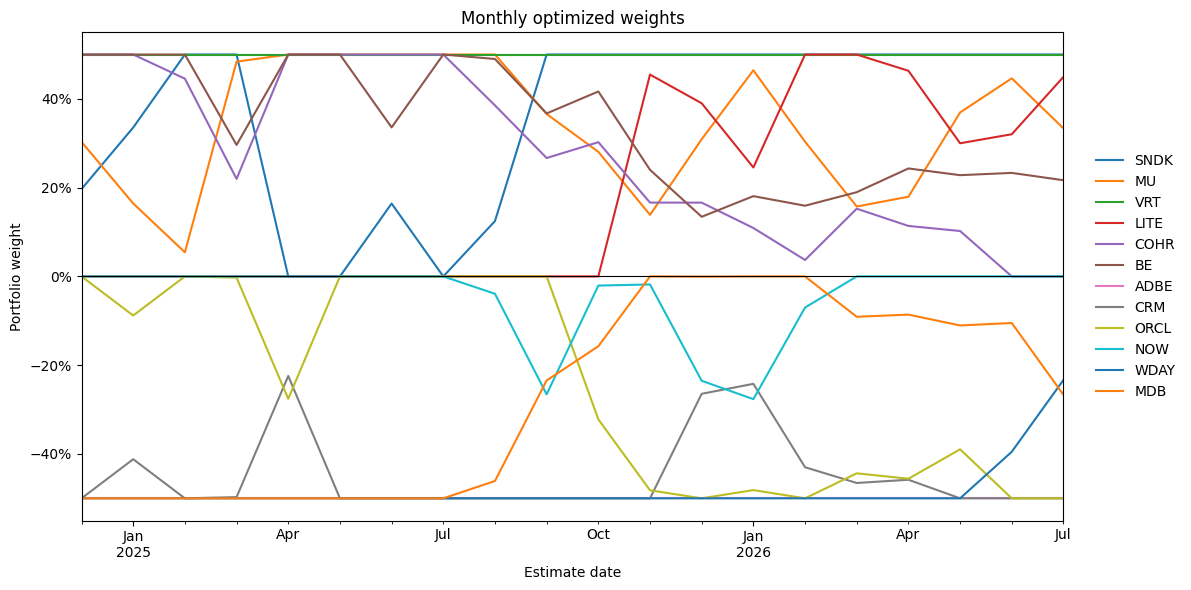

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

test_index = returns.loc[AS_OF:'2026-07-31'].index
estimate_dates = pd.Series(test_index, index=test_index).groupby(test_index.to_period('M')).max()

rolling_weights, rolling_success = {}, {}
for date in estimate_dates:
    window = returns.loc[:date, tickers].tail(WINDOW)
    mu = window.mean() * TRADING_DAYS
    sigma = window.cov() * TRADING_DAYS
    obj = lambda w: -(mu @ w) / np.sqrt(w @ sigma @ w)
    sol = minimize(obj, w0, method=METHOD, bounds=bounds, constraints=cons, tol=TOL)
    rolling_weights[date], rolling_success[date] = sol.x, sol.success

rolling_weights = pd.DataFrame(rolling_weights, index=tickers).T

ax = rolling_weights.plot(figsize=(12, 6), title='Monthly optimized weights')
ax.set(xlabel='Estimate date', ylabel='Portfolio weight')
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.axhline(0, color='black', linewidth=0.8)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

def report_mandate_violations(weights, success, tol=1e-8):
    for date, w in weights.iterrows():
        violations = []
        if not success[date]:
            violations.append('optimization failed')
        if not np.isclose(w[islong].sum(), LONG_BUDGET, atol=tol):
            violations.append('long exposure')
        if not np.isclose(w[~islong].sum(), SHORT_BUDGET, atol=tol):
            violations.append('short exposure')
        if not np.isclose(w.abs().sum(), 4, atol=tol):
            violations.append('gross exposure')
        if not np.isclose(w.sum(), 0, atol=tol):
            violations.append('net exposure')
        if w.abs().max() > CAP + tol:
            violations.append('position cap')
        if violations:
            print(f'{date:%Y-%m-%d}: {", ".join(violations)}')

report_mandate_violations(rolling_weights, rolling_success)

In [20]:
# 4.2: weight ranges, turnover, and the two largest monthly changes
weight_range = rolling_weights.agg(['min', 'max']).T
display(weight_range.style.format('{:.2%}').set_caption('Monthly weight ranges'))

trades = []
for previous, date in zip(rolling_weights.index[:-1], rolling_weights.index[1:]):
    period = returns.loc[(returns.index > previous) & (returns.index <= date), tickers]
    growth = (1 + period).prod()
    drifted = rolling_weights.loc[previous] * growth
    drifted /= 1 + rolling_weights.loc[previous] @ (growth - 1)
    trades.append((rolling_weights.loc[date] - drifted).abs().sum() / 2)


weight_changes = rolling_weights.diff()
largest_months = (weight_changes.abs().sum(axis=1) / 2).nlargest(2)
trace = []
for date, vector_change in largest_months.items():
    previous = rolling_weights.index[rolling_weights.index.get_loc(date) - 1]
    stock = weight_changes.loc[date].abs().idxmax()
    old = returns.loc[:previous, tickers].tail(WINDOW)
    new = returns.loc[:date, tickers].tail(WINDOW)
    old_cov, new_cov = old.cov() * TRADING_DAYS, new.cov() * TRADING_DAYS
    trace.append({
        'month': date.strftime('%Y-%m-%d'), 'previous': previous.strftime('%Y-%m-%d'),
        'monthly one-way target change': vector_change,
        'largest driver': stock, 'weight change': weight_changes.loc[date, stock],
        'mean estimate change': (new[stock].mean() - old[stock].mean()) * TRADING_DAYS,
        'vol estimate change': np.sqrt(new_cov.loc[stock, stock]) - np.sqrt(old_cov.loc[stock, stock]),
        'covariance change with prior portfolio': ((new_cov - old_cov) @ rolling_weights.loc[previous]).loc[stock],
    })

trace = pd.DataFrame(trace).set_index('month')
display(trace.style.format({
    'monthly one-way target change': '{:.2%}', 'weight change': '{:+.2%}',
    'mean estimate change': '{:+.2%}', 'vol estimate change': '{:+.2%}',
    'covariance change with prior portfolio': '{:+.4f}',
}).set_caption('Two largest monthly target changes and estimate changes'))

annual_turnover = 12 * np.mean(trades)
print(f'Annualized one-way turnover: {annual_turnover:.2%}')

,min,max
ticker,,
SNDK,0.00%,50.00%
MU,5.44%,50.00%
VRT,50.00%,50.00%
LITE,0.00%,50.00%
COHR,0.00%,50.00%
BE,13.44%,50.00%
ADBE,-50.00%,-50.00%
CRM,-50.00%,-22.43%
ORCL,-50.00%,0.00%


,previous,monthly one-way target change,largest driver,weight change,mean estimate change,vol estimate change,covariance change with prior portfolio
month,,,,,,,
2025-04-30,2025-03-31,77.31%,SNDK,-50.00%,-11.00%,+4.92%,+0.0393
2025-11-28,2025-10-31,61.47%,LITE,+45.48%,+27.22%,+3.23%,+0.0456


Annualized one-way turnover: 1693.40%


The annualized one-way turnover in of the position-capped optimizer is 1693.40%. The two greatest monthly target change, as shown, are 77.31% and 61.47% respectively. 

# 5 After 2024

## 5.1

From January 2, 2025 through July 31, 2026, compare the monthly rebalanced equal-sleeve and optimized portfolios. Report cumulative return, annualized mean, annualized volatility, Sharpe ratio, maximum drawdown, and worst day. Plot the NAV of $100 million invested in each.

## 5.2

Identify one period in which the two paths separate. Attribute the difference to weights and stock returns. State whether the optimizer benefited from information available before the period or from an outcome it could not have anticipated.

,Equal-Sleeve,Optimized
Cumulative Return,-100.00%,-100.00%
Annualized Mean,207.30%,184.33%
Annualized Volatility,199.29%,212.58%
Sharpe Ratio,1.04,0.87
Max Drawdown,-100.00%,-100.00%
Worst Day,-159.12%,-178.12%


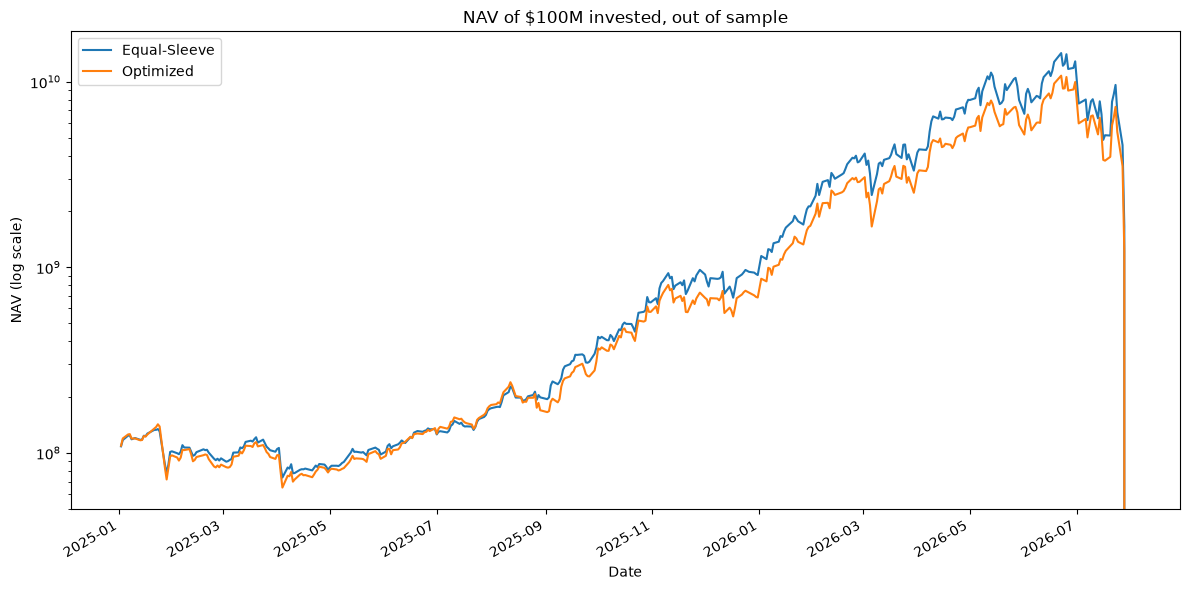

Both portfolios reach NAV = 0 by 2026-07-29, inside the reversal week covered in Section 6.


In [21]:
# === Section 5.1 ===

rebalance_dates = rolling_weights.index
NAV0 = 100_000_000

def nav_path(weight_source, constant=None):
    """Monthly rebalance to target weight * current NAV; buy-and-hold within the month.
    Floors NAV at 0 once the raw path goes non-positive: a 400% gross book can't keep
    re-levering off a wiped-out account. The true (unfloored) return on the wipeout day
    itself is kept for the risk stats; only the displayed NAV path is floored."""
    nav, nav_series, ret_series, wiped = NAV0, {}, {}, False
    for start, end in zip(rebalance_dates[:-1], rebalance_dates[1:]):
        w = (constant if constant is not None else weight_source.loc[start]).astype(float)
        dollar_pos = nav * w
        period = returns.loc[(returns.index > start) & (returns.index <= end), tickers]
        for date, r in period.iterrows():
            if not wiped:
                raw_nav = nav + (dollar_pos * r).sum()
                ret_series[date] = raw_nav / nav - 1
                dollar_pos *= (1 + r)
                nav = max(raw_nav, 0.0)
                if raw_nav <= 0:
                    wiped = True
            nav_series[date] = nav
    return pd.Series(nav_series), pd.Series(ret_series)

nav_optimized, ret_optimized = nav_path(rolling_weights)
nav_equal, ret_equal = nav_path(None, constant=w0)

def path_stats(nav, ret):
    return pd.Series({
        'Cumulative Return': nav.iloc[-1] / NAV0 - 1,
        'Annualized Mean': ret.mean() * TRADING_DAYS,
        'Annualized Volatility': ret.std() * np.sqrt(TRADING_DAYS),
        'Sharpe Ratio': (ret.mean() * TRADING_DAYS) / (ret.std() * np.sqrt(TRADING_DAYS)),
        'Max Drawdown': (nav / nav.cummax() - 1).min(),
        'Worst Day': ret.min(),
    })

summary_5_1 = pd.DataFrame({
    'Equal-Sleeve': path_stats(nav_equal, ret_equal),
    'Optimized': path_stats(nav_optimized, ret_optimized),
})
display(
    summary_5_1.style
    .format('{:.2%}')
    .format('{:.2f}', subset=pd.IndexSlice[['Sharpe Ratio'], :])
    .set_caption('Out-of-sample, 2025-01-02 to 2026-07-31')
)

ax = pd.DataFrame({'Equal-Sleeve': nav_equal, 'Optimized': nav_optimized}).plot(
    figsize=(12, 6), logy=True, title='NAV of $100M invested, out of sample'
)
ax.set(xlabel='Date', ylabel='NAV (log scale)')
plt.tight_layout()
plt.show()

print(f'Both portfolios reach NAV = 0 by {nav_optimized[nav_optimized.eq(0)].index[0]:%Y-%m-%d}, '
      'inside the reversal week covered in Section 6.')


**Both portfolios are wiped out.** Equal sleeves compounds $100M to a peak near **$13.1B** by June 2026 (a **1.04** Sharpe out of sample), the optimized book peaks lower near **$10.3B** (Sharpe **0.87**), and both go to **NAV = 0** on **2026-07-29**, inside the reversal week Section 6 covers. Worst single day is **-159%** for equal sleeves and **-178%** for optimized: at 400% gross, a bad day can lose more than the account is worth, which is exactly what happens.

Equal sleeves comes out ahead on every stat that isn't already floored at the wipeout (higher mean, lower vol, higher Sharpe). The next part traces why.


**The clearest separation is October 31 to November 28, 2025.** The optimized book held **0% LITE** that month (funding the long sleeve elsewhere) against equal sleeve's fixed **33.3%**. LITE returned **+61.3%** in November, so that single weight gap cost the optimized portfolio about **23 percentage points** of relative return in one month, the largest monthly gap anywhere in the sample.

This isn't a one-off. The same pattern shows up with **SNDK** in August 2025 (optimizer at 0%, SNDK +22.3%) and again with **BE** in April 2026 (optimizer at 19%, BE +109.1%): the trailing-window optimizer keeps rotating away from whichever long name is about to have its best month, funding the other names instead. That's the mean-estimation instability from Section 2 showing up out of sample, not a coincidence.

The November 2025 LITE weight was set using only data through October 31, 2025, no lookahead. The optimizer didn't have stale information going into that month; it simply couldn't have anticipated LITE's November rally from what a 756-day trailing window showed at the time. Equal sleeves wins this stretch by not making that bet in the first place, not by making a better one.


# 6 The Reversal and the Allocation

## 6.1

For the July 24 through July 29, 2026 reversal, report the return and dollar P&L of each portfolio. Attribute each result to the long sleeve, short sleeve, and three largest stock contributions. Explain which earlier weight decisions mattered most.

## 6.2

Apply the two criteria declared in Section 2. Choose equal sleeves or your optimized allocation at the July 31, 2026 close. Report the weights you would use. Name one observable result over the next year that would reverse the choice and state how you would measure it.

Follow [Project Guidelines](../Project%20Guidelines.md).